In [1]:
from google.colab import files
import pandas as pd
import io

print("Please upload your dataset file. For example, a CSV file.")
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
  try:
    df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')))
    print(f'Successfully loaded "{fn}" into a pandas DataFrame. Here are the first 5 rows:')
    print(df.head())
  except Exception as e:
    print(f'Could not read "{fn}" as a CSV. Error: {e}')
    print('You might need to adjust the loading method based on your file type (e.g., pd.read_excel for .xlsx, pd.read_json for .json).')

Please upload your dataset file. For example, a CSV file.


Saving diabetes.csv to diabetes.csv
User uploaded file "diabetes.csv" with length 23873 bytes
Successfully loaded "diabetes.csv" into a pandas DataFrame. Here are the first 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Exploratory Data Analysis

In [4]:
print(f"Shape of the DataFrame: {df.shape}")
print("\nMissing values per column:")
print(df.isnull().sum())

Shape of the DataFrame: (768, 9)

Missing values per column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


## Analyzing Target Variable Distribution



To investigate the distribution of the target variable 'Outcome', I will calculate and display its value counts and percentage distribution. Then, I will visualize this distribution using a bar plot for a clear understanding of its balance and characteristics.



Value counts for 'Outcome' column:
Outcome
0    500
1    268
Name: count, dtype: int64


Percentage distribution for 'Outcome' column:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64




/tmp/ipykernel_457/3182016479.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=outcome_counts.index, y=outcome_counts.values, palette='viridis')


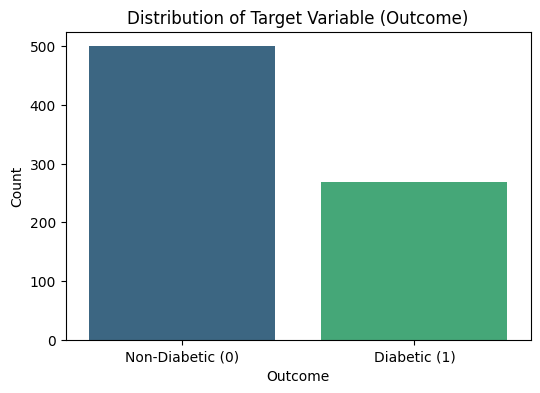

In [5]:
# Analyzing Target Variable Distribution
import matplotlib.pyplot as plt
import seaborn as sns

# Calculating the value counts for the 'Outcome' column
outcome_counts = df['Outcome'].value_counts()

# Lets Display these value counts
print("Value counts for 'Outcome' column:")
print(outcome_counts)
print("\n")

# Calculating and displaying the percentage distribution of each class
outcome_percentage = df['Outcome'].value_counts(normalize=True) * 100
print("Percentage distribution for 'Outcome' column:")
print(outcome_percentage)
print("\n")

# Creating a bar plot to visualize the distribution of the 'Outcome' variable
plt.figure(figsize=(6, 4))
sns.barplot(x=outcome_counts.index, y=outcome_counts.values, palette='viridis')
plt.title('Distribution of Target Variable (Outcome)')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Non-Diabetic (0)', 'Diabetic (1)'])
plt.show()

## Exploring the Feature Distributions by Class


Lets Visualize and analyze the distribution of each feature separately for each class of the target variable to identify patterns.


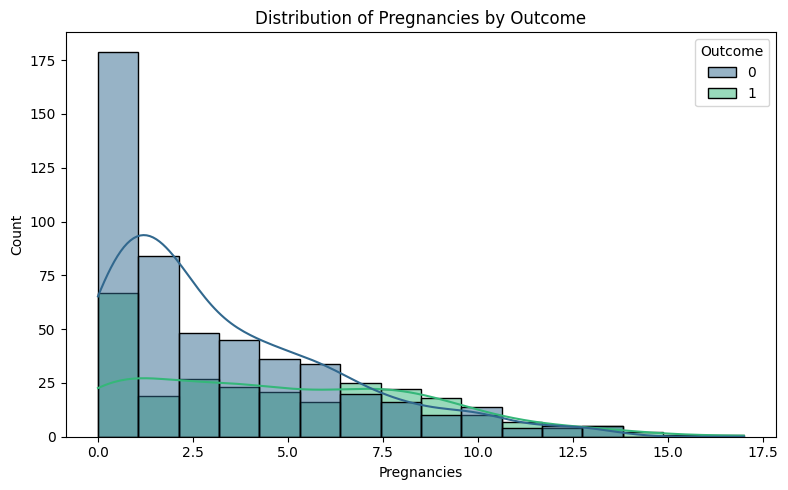

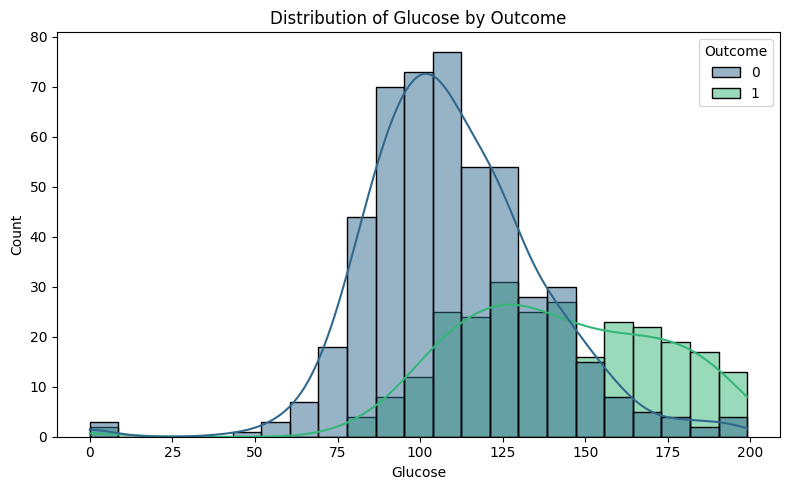

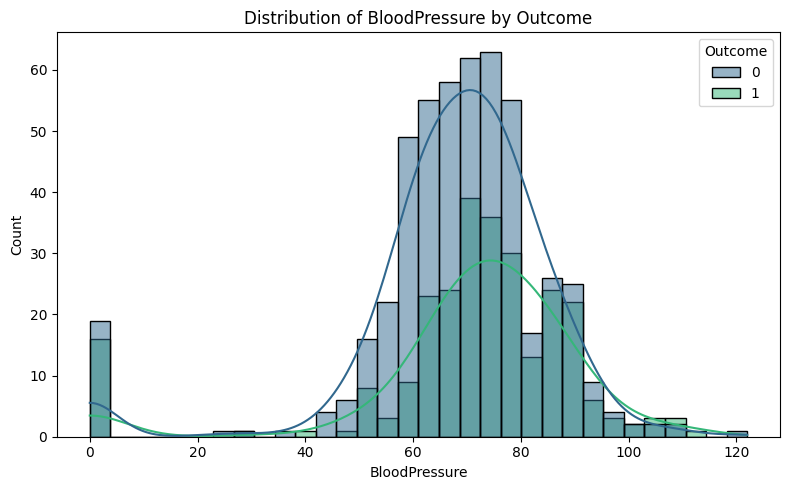

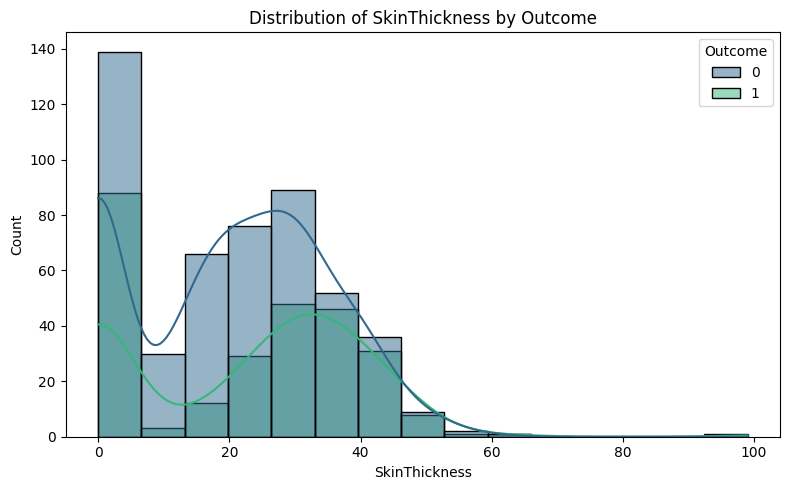

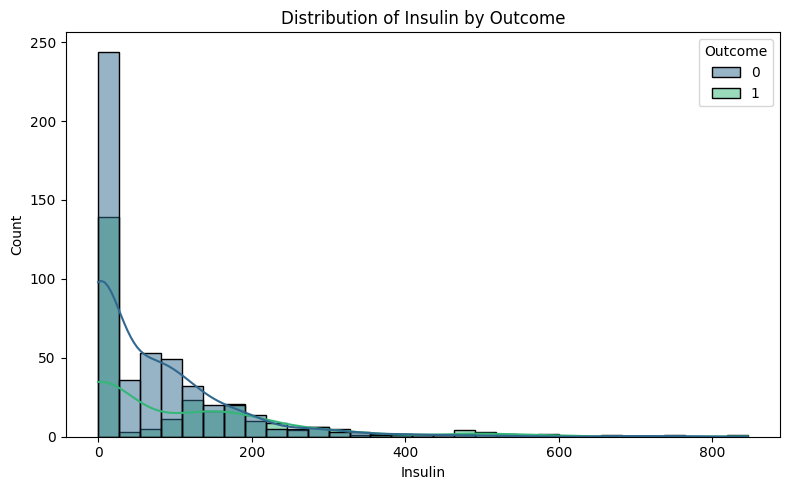

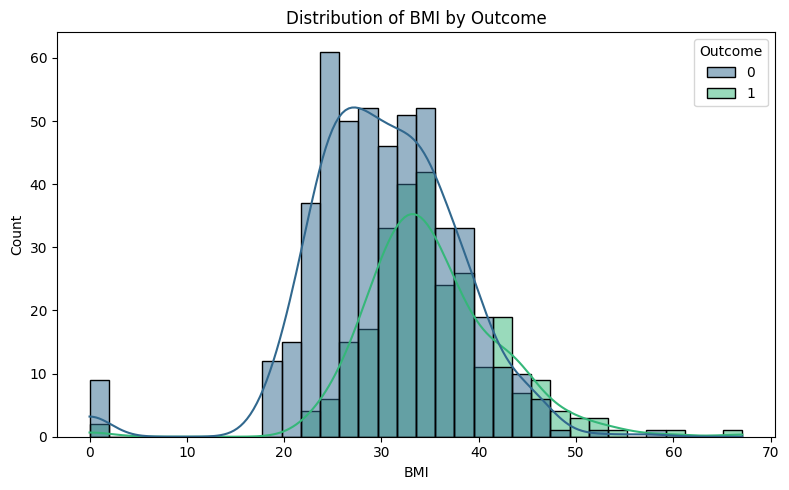

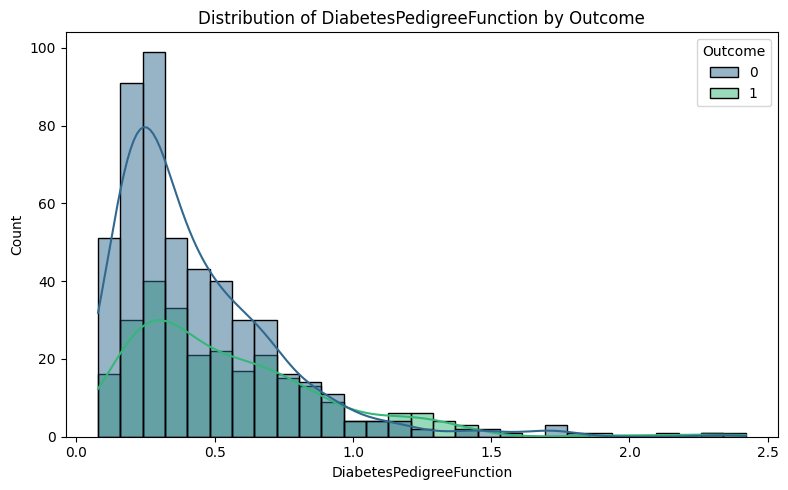

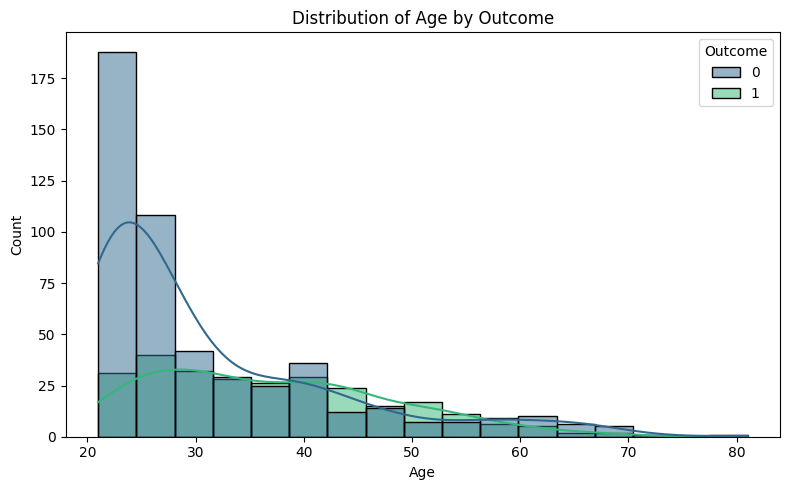

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Geting a list of all column names in the DataFrame, excluding the 'Outcome' column
features = df.columns.drop('Outcome')

# Iterating through each feature in this list
for feature in features:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=feature, hue='Outcome', kde=True, palette='viridis')
    plt.title(f'Distribution of {feature} by Outcome')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

## Detecting Outliers in Numerical Features

To identify potential outliers in numerical features, I will generate box plots for each feature, excluding the target variable 'Outcome', as box plots are effective visualization techniques for detecting outliers.


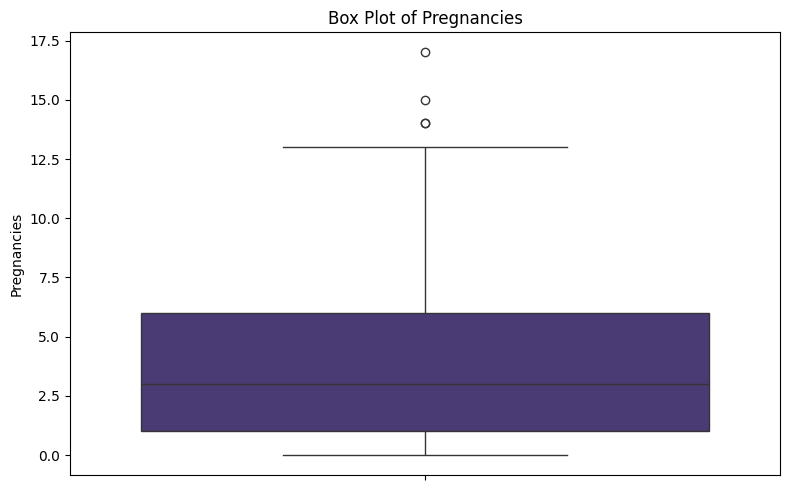

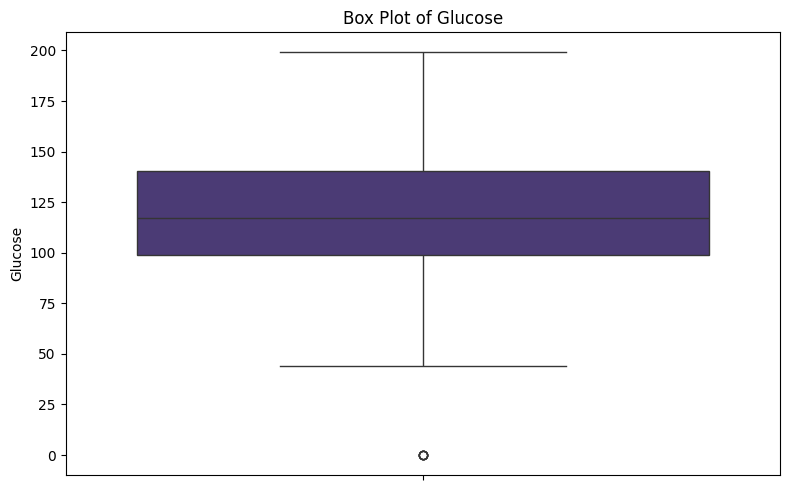

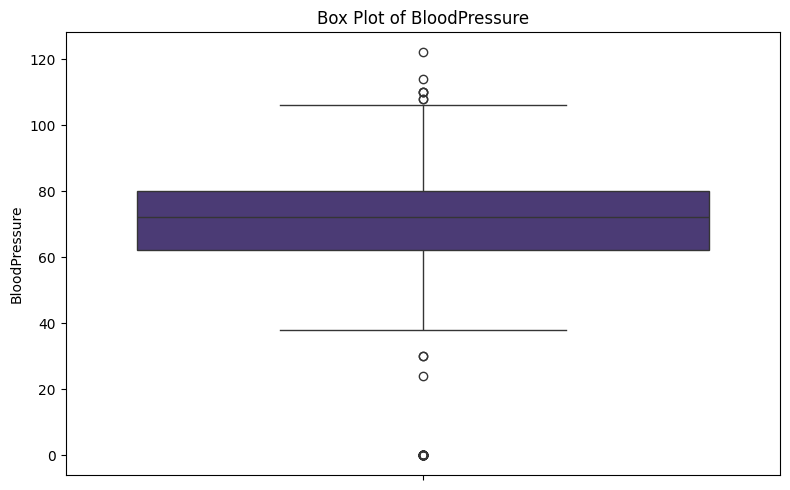

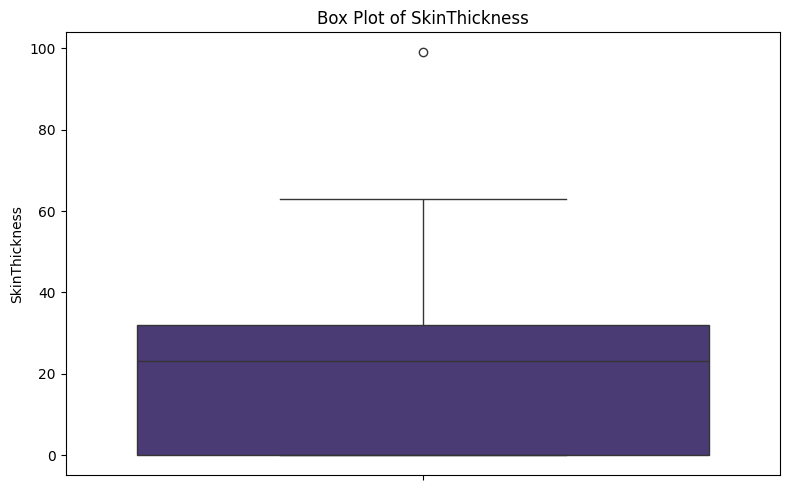

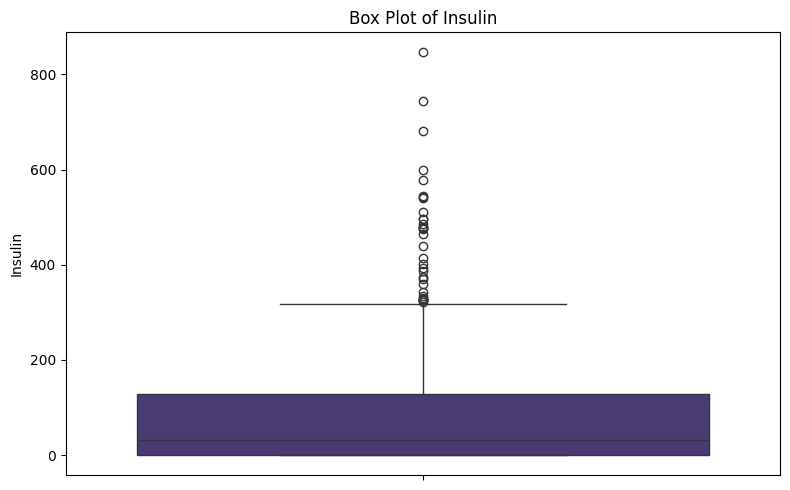

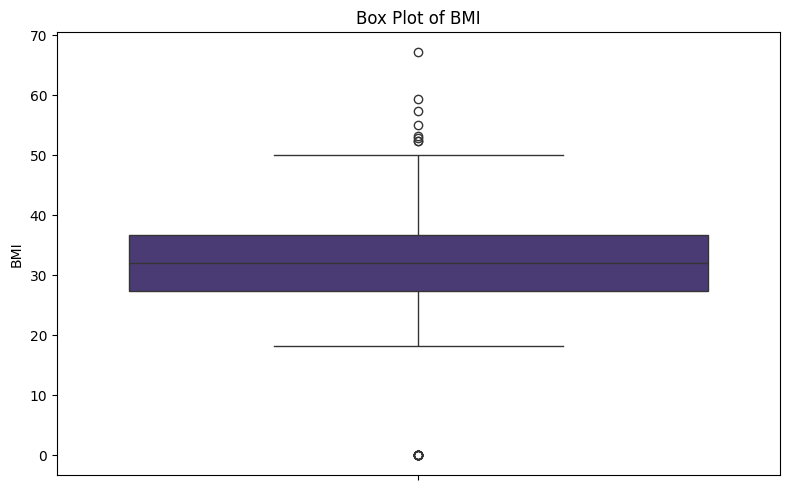

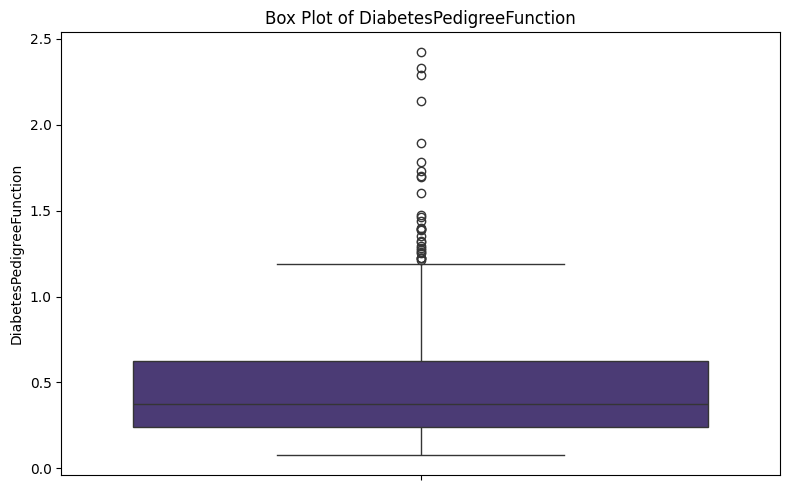

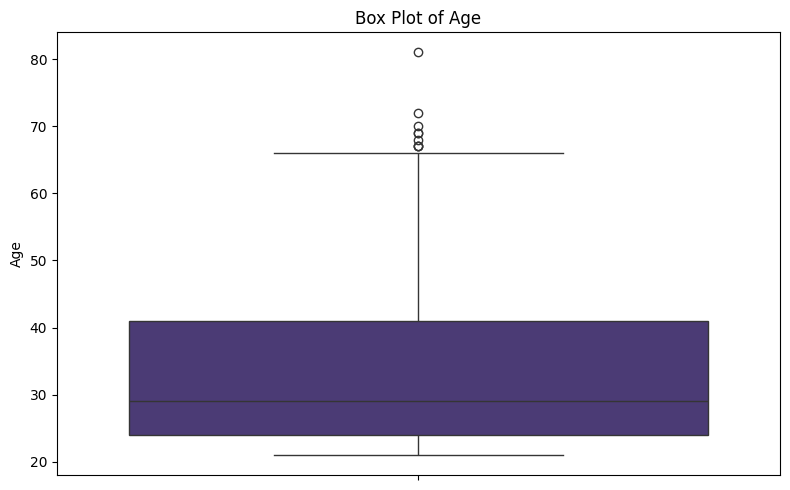

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get a list of all numerical column names in the DataFrame, excluding the 'Outcome' column
numerical_features = df.columns.drop('Outcome')

# Get the first color from the 'viridis' palette for consistency
default_boxplot_color = sns.color_palette('viridis')[0]

# Iterate through each numerical feature in this list
for feature in numerical_features:
    plt.figure(figsize=(8, 5))
    # Use 'color' instead of 'palette' for a single boxplot to avoid the FutureWarning
    sns.boxplot(y=df[feature], color=default_boxplot_color)
    plt.title(f'Box Plot of {feature}')
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

## Calculating Feature-Feature Correlation


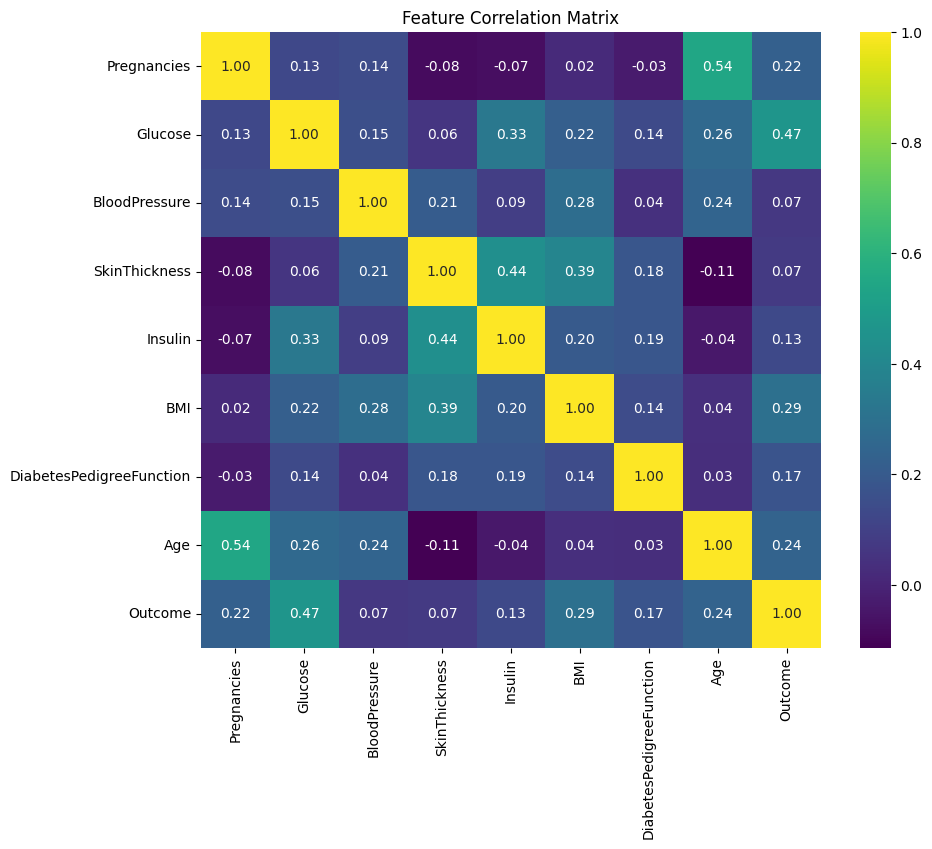

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix for all features
correlation_matrix = df.corr()

# Create a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='viridis', fmt='.2f')

# Adding a title to the heatmap
plt.title('Feature Correlation Matrix')

plt.show()

Feature-Target Correlation (Absolute Values, Sorted Descending):
Glucose                     0.492928
BMI                         0.311924
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.215299
Insulin                     0.214411
DiabetesPedigreeFunction    0.173844
BloodPressure               0.166074
dtype: float64


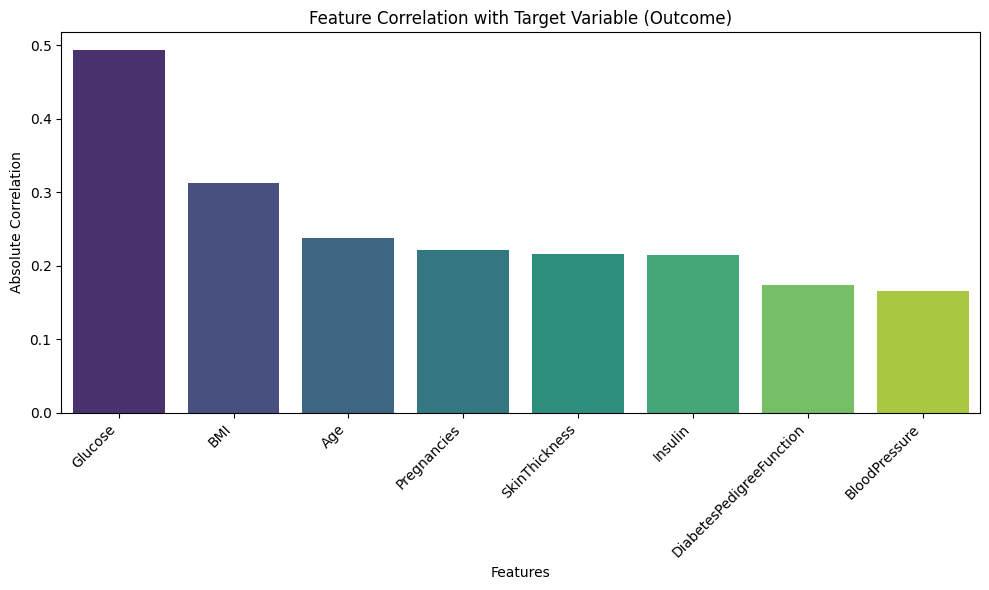

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculating the correlation of each feature with the 'Outcome' variable
# We use df_cleaned as it has the imputed zero values
feature_target_correlation = df_cleaned.corrwith(df_cleaned['Outcome']).abs()

# Drop the correlation of 'Outcome' with itself, as it will always be 1
feature_target_correlation = feature_target_correlation.drop('Outcome')

# Sorting the correlations in descending order for better visualization
feature_target_correlation = feature_target_correlation.sort_values(ascending=False)

print("Feature-Target Correlation (Absolute Values, Sorted Descending):")
print(feature_target_correlation)

# Creating a bar plot to visualize the feature-target correlations
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_target_correlation.index, y=feature_target_correlation.values, hue=feature_target_correlation.index, palette='viridis', legend=False)
plt.title('Feature Correlation with Target Variable (Outcome)')
plt.xlabel('Features')
plt.ylabel('Absolute Correlation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Handling Biologically Implausible Zero Values

Certain features in medical datasets, like 'Glucose' or 'BloodPressure', cannot realistically have a value of zero. These '0' values often represent missing data or data entry errors. To address this, we will replace these biologically impossible '0's with the mean of the non-zero values for the respective features. This approach helps to preserve the overall distribution of the data while correcting erroneous entries.

In [ ]:
import numpy as np

# List of features where '0' values are biologically implausible
features_to_impute_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Creating a copy to work on, to avoid modifying the original df directly unless intended
df_cleaned = df.copy()

for feature in features_to_impute_zeros:
    # Calculate the mean of non-zero values for the current feature
    # np.where is used to select non-zero values. If a value is 0, it is ignored.
    mean_value = df_cleaned[df_cleaned[feature] != 0][feature].mean()

    # Replace '0' values with the calculated mean
    df_cleaned[feature] = df_cleaned[feature].replace(0, mean_value)

    print(f"Feature '{feature}': Replaced 0s with mean of non-zero values ({mean_value:.2f})")

print("\nFirst 5 rows of the DataFrame after replacing 0s:")
print(df_cleaned.head())

Feature 'Glucose': Replaced 0s with mean of non-zero values (121.69)
Feature 'BloodPressure': Replaced 0s with mean of non-zero values (72.41)
Feature 'SkinThickness': Replaced 0s with mean of non-zero values (29.15)
Feature 'Insulin': Replaced 0s with mean of non-zero values (155.55)
Feature 'BMI': Replaced 0s with mean of non-zero values (32.46)

First 5 rows of the DataFrame after replacing 0s:
   Pregnancies  Glucose  BloodPressure  SkinThickness     Insulin   BMI  \
0            6    148.0           72.0       35.00000  155.548223  33.6   
1            1     85.0           66.0       29.00000  155.548223  26.6   
2            8    183.0           64.0       29.15342  155.548223  23.3   
3            1     89.0           66.0       23.00000   94.000000  28.1   
4            0    137.0           40.0       35.00000  168.000000  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2               

After replacing the '0' values in the specified features with their respective non-zero means, the dataset (`df_cleaned`) now reflects a more accurate representation of these biological parameters. This step helps in improving the quality of the data for further analysis and model training.

Now, let's re-examine the descriptive statistics for these features to see the impact of this imputation.

In [ ]:
print(df_cleaned[features_to_impute_zeros].describe())

          Glucose  BloodPressure  SkinThickness     Insulin         BMI
count  768.000000     768.000000     768.000000  768.000000  768.000000
mean   121.686763      72.405184      29.153420  155.548223   32.457464
std     30.435949      12.096346       8.790942   85.021108    6.875151
min     44.000000      24.000000       7.000000   14.000000   18.200000
25%     99.750000      64.000000      25.000000  121.500000   27.500000
50%    117.000000      72.202592      29.153420  155.548223   32.400000
75%    140.250000      80.000000      32.000000  155.548223   36.600000
max    199.000000     122.000000      99.000000  846.000000   67.100000


In [ ]:
import numpy as np

# Identify numerical features, excluding the target variable
numerical_features = df.columns.drop('Outcome')

outliers_summary = {}

for feature in numerical_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers
    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    outliers_count = outliers.shape[0]
    percentage_outliers = (outliers_count / df.shape[0]) * 100

    outliers_summary[feature] = {
        'count': outliers_count,
        'percentage': f'{percentage_outliers:.2f}%',
        'lower_bound': lower_bound,
        'upper_bound': upper_bound
    }

print("Outlier Detection using IQR Method:")
for feature, data in outliers_summary.items():
    print(f"\nFeature: {feature}")
    print(f"  Outlier Count: {data['count']}")
    print(f"  Percentage of Outliers: {data['percentage']}")
    print(f"  Lower Bound: {data['lower_bound']:.2f}")
    print(f"  Upper Bound: {data['upper_bound']:.2f}")

Outlier Detection using IQR Method:

Feature: Pregnancies
  Outlier Count: 4
  Percentage of Outliers: 0.52%
  Lower Bound: -6.50
  Upper Bound: 13.50

Feature: Glucose
  Outlier Count: 5
  Percentage of Outliers: 0.65%
  Lower Bound: 37.12
  Upper Bound: 202.12

Feature: BloodPressure
  Outlier Count: 45
  Percentage of Outliers: 5.86%
  Lower Bound: 35.00
  Upper Bound: 107.00

Feature: SkinThickness
  Outlier Count: 1
  Percentage of Outliers: 0.13%
  Lower Bound: -48.00
  Upper Bound: 80.00

Feature: Insulin
  Outlier Count: 34
  Percentage of Outliers: 4.43%
  Lower Bound: -190.88
  Upper Bound: 318.12

Feature: BMI
  Outlier Count: 19
  Percentage of Outliers: 2.47%
  Lower Bound: 13.35
  Upper Bound: 50.55

Feature: DiabetesPedigreeFunction
  Outlier Count: 29
  Percentage of Outliers: 3.78%
  Lower Bound: -0.33
  Upper Bound: 1.20

Feature: Age
  Outlier Count: 9
  Percentage of Outliers: 1.17%
  Lower Bound: -1.50
  Upper Bound: 66.50


### Discussing Outlier Handling Strategies

Now that we have quantified the outliers for each feature, we need to decide on an appropriate handling strategy. Here are some common approaches:

1.  **Removal**: If outliers are clearly data entry errors or represent rare events that are not relevant to the modeling goal, they can be removed. However, this can lead to loss of valuable data.
2.  **Transformation**: Applying mathematical transformations (e.g., logarithmic, square root) can reduce the impact of outliers by compressing the range of values. This is useful when the distribution is skewed.
3.  **Imputation/Capping**: Outliers can be replaced with a less extreme value (capping/winsorization) or imputed using statistical methods (e.g., mean, median, or a more sophisticated model) if they are deemed genuine but highly influential.

Considering the nature of our dataset and the detected outliers, we should carefully evaluate each feature. For example, some '0' values in features like 'Glucose', 'BloodPressure', and 'BMI' might be physiologically impossible and could be treated as missing values to be imputed, rather than true outliers. For other features with a reasonable spread, transformation or capping might be more appropriate.


## Remove outliers using IQR method

In [10]:
import numpy as np

# 1. Initialize df_no_outliers as a copy of df_cleaned
df_no_outliers = df_cleaned.copy()

# 2. Get a list of all numerical column names from df_cleaned, excluding the 'Outcome' column
numerical_features = df_cleaned.columns.drop('Outcome')

original_shape = df_no_outliers.shape
print(f"Original shape of df_no_outliers: {original_shape}")

# 3. Iterate through each numerical feature and remove outliers
for feature in numerical_features:
    Q1 = df_no_outliers[feature].quantile(0.25)
    Q3 = df_no_outliers[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter rows to keep only those within the bounds
    df_no_outliers = df_no_outliers[
        (df_no_outliers[feature] >= lower_bound) & (df_no_outliers[feature] <= upper_bound)
    ]
    print(f"After processing '{feature}', shape is: {df_no_outliers.shape}")

print(f"\nFinal shape of df_no_outliers after removing all outliers: {df_no_outliers.shape}")
print("First 5 rows of df_no_outliers after outlier removal:")
print(df_no_outliers.head())

Original shape of df_no_outliers: (768, 9)
After processing 'Pregnancies', shape is: (764, 9)
After processing 'Glucose', shape is: (764, 9)
After processing 'BloodPressure', shape is: (750, 9)
After processing 'SkinThickness', shape is: (665, 9)
After processing 'Insulin', shape is: (497, 9)
After processing 'BMI', shape is: (491, 9)
After processing 'DiabetesPedigreeFunction', shape is: (467, 9)
After processing 'Age', shape is: (462, 9)

Final shape of df_no_outliers after removing all outliers: (462, 9)
First 5 rows of df_no_outliers after outlier removal:
   Pregnancies  Glucose  BloodPressure  SkinThickness     Insulin   BMI  \
0            6    148.0           72.0       35.00000  155.548223  33.6   
1            1     85.0           66.0       29.00000  155.548223  26.6   
2            8    183.0           64.0       29.15342  155.548223  23.3   
3            1     89.0           66.0       23.00000   94.000000  28.1   
5            5    116.0           74.0       29.15342  155

## Summary:

### Data Analysis Key Findings

*   The dataset contains 768 rows and 9 columns, with no missing values detected across any of the columns, indicating a complete dataset.
*   The target variable, 'Outcome', shows an imbalanced distribution:
    *   Class 0 (Non-Diabetic) accounts for 500 instances (65.10%).
    *   Class 1 (Diabetic) accounts for 268 instances (34.90%).
*   Feature distributions were visualized by target class, providing initial insights into how each feature's values differ between diabetic and non-diabetic individuals.
*   Outliers in numerical features were identified using box plots, suggesting potential data cleaning or transformation steps might be necessary for certain features.
*   A correlation matrix was computed and visualized, showing the relationships between all features. This helps in understanding multicollinearity and identifying potentially strong predictors.

### Insights or Next Steps

*   Address the class imbalance in the 'Outcome' variable during model training to prevent bias towards the majority class (e.g., using techniques like oversampling, undersampling, or appropriate evaluation metrics).
*   Investigate the identified outliers further to determine if they are data entry errors or genuine extreme values, and decide on appropriate handling strategies (e.g., removal, transformation, or imputation).


### Addressing Class Imbalance with SMOTE

Class imbalance can lead to models that perform poorly on the minority class. To mitigate this, we will use the **Synthetic Minority Over-sampling Technique (SMOTE)**. SMOTE works by creating synthetic samples for the minority class, rather than simply duplicating existing ones, thereby reducing the risk of overfitting.

First, we need to separate our features (X) from our target variable (y). Then, we will apply SMOTE to rebalance the dataset.

Original dataset shape: Counter({0: 500, 1: 268})
Resampled dataset shape: Counter({1: 500, 0: 500})


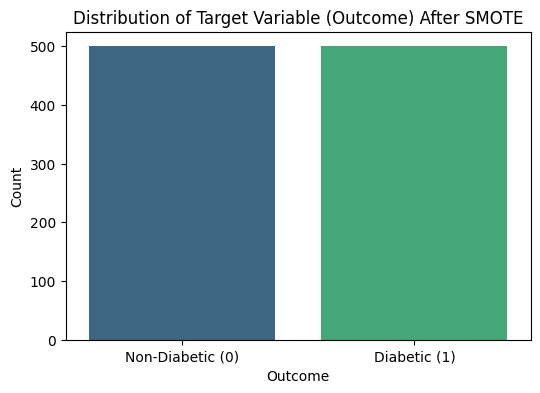

In [11]:
from imblearn.over_sampling import SMOTE
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Separate features (X) and target (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

print(f"Original dataset shape: {Counter(y)}")

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"Resampled dataset shape: {Counter(y_resampled)}")

# Visualize the new distribution
plt.figure(figsize=(6, 4))
sns.barplot(x=list(Counter(y_resampled).keys()), y=list(Counter(y_resampled).values()), palette='viridis', hue=list(Counter(y_resampled).keys()), legend=False)
plt.title('Distribution of Target Variable (Outcome) After SMOTE')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Non-Diabetic (0)', 'Diabetic (1)'])
plt.show()

In [12]:
!pip install xgboost

## Training a Random Forest Model

## Splitting Data into Training and Testing Sets (SMOTE Data)

Now that we have the class-balanced dataset (`X_resampled`, `y_resampled`) from SMOTE, I will split it into training and testing sets. This is a crucial step to evaluate the models on unseen data and ensure their generalization performance.

In [14]:
from sklearn.model_selection import train_test_split

# Split the resampled data (from SMOTE) into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

print("Data split into training and testing sets using SMOTE resampled data.")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Data split into training and testing sets using SMOTE resampled data.
X_train shape: (800, 8)
y_train shape: (800,)
X_test shape: (200, 8)
y_test shape: (200,)


In [19]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Train the model using the training data
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


## Training a Gradient Boosting Model

In [22]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize the Gradient Boosting model
gb_model = GradientBoostingClassifier(random_state=42)

# Train the model using the training data
gb_model.fit(X_train, y_train)

print("Gradient Boosting model trained successfully!")

Gradient Boosting model trained successfully!


## Training an XGBoost Model

In [21]:
from xgboost import XGBClassifier

# Initialize the XGBoost model
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss') # Suppress warning for use_label_encoder and set eval_metric

# Train the model using the training data
xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:59:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Training a Logistic Regression Model


In [20]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' solver is good for small datasets

# Train the model using the training data
log_reg_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


## Model Evaluation

Now that we have trained multiple machine learning models, Lets evaluate their performance on the test dataset. This will help us compare the models and select the best one for our prediction task.

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(model, X_test, y_test, model_name):
    """Evaluates a given model and prints classification metrics."""
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    print(f"==== {model_name} Evaluation ====")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC-ROC: {roc_auc:.4f}")
    print("\n")

# Evaluate Logistic Regression Model
evaluate_model(log_reg_model, X_test, y_test, "Logistic Regression")

# Evaluate Random Forest Model
evaluate_model(rf_model, X_test, y_test, "Random Forest")

# Evaluate Gradient Boosting Model
evaluate_model(gb_model, X_test, y_test, "Gradient Boosting")

# Evaluate XGBoost Model
evaluate_model(xgb_model, X_test, y_test, "XGBoost")

==== Logistic Regression Evaluation ====
Accuracy: 0.7500
Precision: 0.7551
Recall: 0.7400
F1-Score: 0.7475
AUC-ROC: 0.8277


==== Random Forest Evaluation ====
Accuracy: 0.8200
Precision: 0.7963
Recall: 0.8600
F1-Score: 0.8269
AUC-ROC: 0.9190


==== Gradient Boosting Evaluation ====
Accuracy: 0.7900
Precision: 0.7788
Recall: 0.8100
F1-Score: 0.7941
AUC-ROC: 0.8798


==== XGBoost Evaluation ====
Accuracy: 0.8200
Precision: 0.8019
Recall: 0.8500
F1-Score: 0.8252
AUC-ROC: 0.8901




## ROC-AUC Interpretation & Threshold Tuning

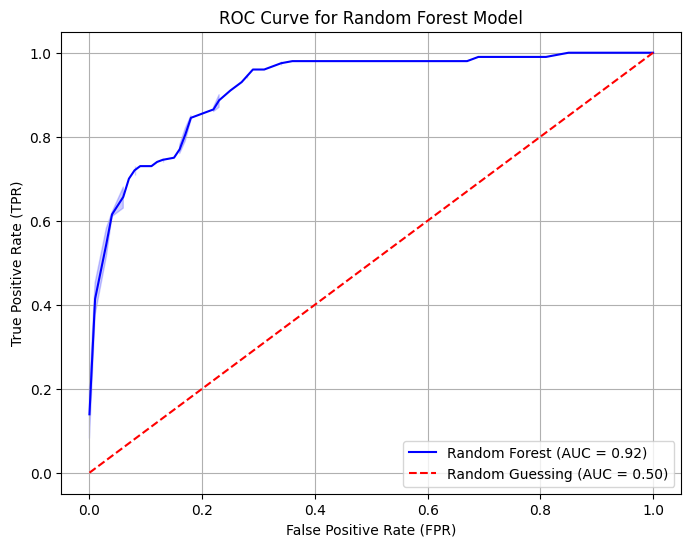

Random Forest Model AUC-ROC Score: 0.9190


In [24]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Get predicted probabilities for the positive class from the Random Forest model
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_rf)

# Calculate AUC
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
sns.lineplot(x=fpr, y=tpr, label=f'Random Forest (AUC = {roc_auc:.2f})', color='blue')
plt.plot([0, 1], [0, 1], 'r--', label='Random Guessing (AUC = 0.50)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve for Random Forest Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"Random Forest Model AUC-ROC Score: {roc_auc:.4f}")

## Introduce RandomOverSampler

### What is RandomOverSampler?
**RandomOverSampler** is a simple yet effective technique used to handle imbalanced datasets by increasing the number of instances in the minority class. It works by **randomly duplicating existing samples** from the minority class until the class distribution is balanced or reaches a desired ratio. This process helps to prevent machine learning models from becoming biased towards the majority class.

### How it works:
1.  Identifies the minority class (the class with fewer samples).
2.  Randomly selects samples from the minority class.
3.  Creates exact copies of these selected samples.
4.  Adds these duplicated samples to the dataset until the desired balance is achieved.

### How it differs from SMOTE:
While both `RandomOverSampler` and SMOTE (Synthetic Minority Over-sampling Technique) aim to balance class distribution, their fundamental approaches differ significantly:

*   **RandomOverSampler (Duplication-based):**
    *   Works by **duplicating existing samples** from the minority class.
    *   Does not create new, synthetic data points.
    *   Can lead to overfitting if not used carefully, as the model might learn specific duplicated instances too well.
    *   Simpler and computationally less intensive.

*   **SMOTE (Synthesis-based):**
    *   Works by **generating synthetic samples** for the minority class.
    *   It creates new data points that are combinations of existing minority class samples and their nearest neighbors.
    *   Helps to mitigate overfitting compared to simple duplication by creating varied samples.
    *   More complex and computationally intensive than `RandomOverSampler`.

### Applying RandomOverSampler

To address class imbalance without generating synthetic samples, we will use `RandomOverSampler`. This technique randomly duplicates samples from the minority class to balance the class distribution. This approach is simpler than SMOTE and can be effective, especially when the dataset is not too complex.

We will perform the following steps:
1.  Import `RandomOverSampler`.
2.  Separate features (`X`) and target (`y`) from the `df_cleaned` DataFrame (which has biologically implausible zeros imputed).
3.  Display the original class distribution.
4.  Apply `RandomOverSampler` to create a balanced dataset.
5.  Display the new, balanced class distribution.
6.  Visualize the balanced class distribution using a bar plot.

Original dataset shape: Counter({0: 500, 1: 268})
Resampled dataset shape after RandomOverSampler: Counter({1: 500, 0: 500})


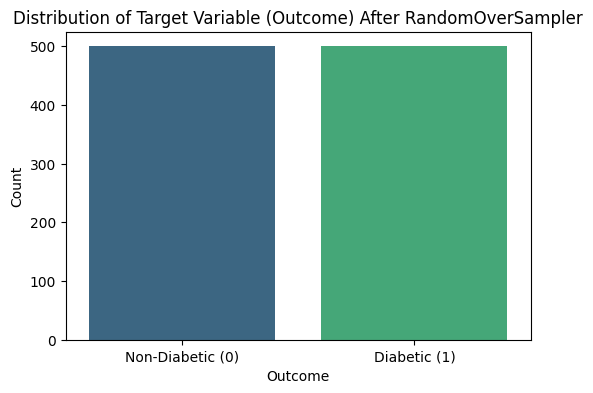

In [ ]:
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Separate features (X) and target (y) from the df_cleaned DataFrame
X = df_cleaned.drop('Outcome', axis=1)
y = df_cleaned['Outcome']

print(f"Original dataset shape: {Counter(y)}")

# Instantiate RandomOverSampler
ros = RandomOverSampler(random_state=42)

# Apply RandomOverSampler
X_ros_resampled, y_ros_resampled = ros.fit_resample(X, y)

print(f"Resampled dataset shape after RandomOverSampler: {Counter(y_ros_resampled)}")

# Visualize the new distribution
plt.figure(figsize=(6, 4))
sns.barplot(x=list(Counter(y_ros_resampled).keys()), y=list(Counter(y_ros_resampled).values()), palette='viridis', hue=list(Counter(y_ros_resampled).keys()), legend=False)
plt.title('Distribution of Target Variable (Outcome) After RandomOverSampler')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Non-Diabetic (0)', 'Diabetic (1)'])
plt.show()

Now that the data has been resampled using `RandomOverSampler`, I will split the `X_ros_resampled` and `y_ros_resampled` into training and testing sets. This is a standard preprocessing step before training machine learning models to ensure proper evaluation.



In [ ]:
from sklearn.model_selection import train_test_split

# Split the resampled data into training and testing sets
X_ros_train, X_ros_test, y_ros_train, y_ros_test = train_test_split(X_ros_resampled, y_ros_resampled, test_size=0.2, random_state=42, stratify=y_ros_resampled)

print("Data split into training and testing sets using RandomOverSampler resampled data.")
print(f"X_ros_train shape: {X_ros_train.shape}")
print(f"y_ros_train shape: {y_ros_train.shape}")
print(f"X_ros_test shape: {X_ros_test.shape}")
print(f"y_ros_test shape: {y_ros_test.shape}")

Data split into training and testing sets using RandomOverSampler resampled data.
X_ros_train shape: (800, 8)
y_ros_train shape: (800,)
X_ros_test shape: (200, 8)
y_ros_test shape: (200,)


I will retrain the Logistic Regression model using the `RandomOverSampler` training data (`X_ros_train`, `y_ros_train`) to ensure it learns from the balanced dataset.



In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
log_reg_model_ros = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' solver is good for small datasets

# Train the model using the resampled training data
log_reg_model_ros.fit(X_ros_train, y_ros_train)

print("Logistic Regression model retrained successfully with RandomOverSampler data!")

Logistic Regression model retrained successfully with RandomOverSampler data!


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest model
rf_model_ros = RandomForestClassifier(random_state=42)

# Train the model using the resampled training data
rf_model_ros.fit(X_ros_train, y_ros_train)

print("Random Forest model retrained successfully with RandomOverSampler data!")

Random Forest model retrained successfully with RandomOverSampler data!


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize the Gradient Boosting model
gb_model_ros = GradientBoostingClassifier(random_state=42)

# Train the model using the resampled training data
gb_model_ros.fit(X_ros_train, y_ros_train)

print("Gradient Boosting model retrained successfully with RandomOverSampler data!")

Gradient Boosting model retrained successfully with RandomOverSampler data!


In [ ]:
from xgboost import XGBClassifier

# Initialize the XGBoost model
xgb_model_ros = XGBClassifier(random_state=42, eval_metric='logloss') # Removed use_label_encoder

# Train the model using the resampled training data
xgb_model_ros.fit(X_ros_train, y_ros_train)

print("XGBoost model retrained successfully with RandomOverSampler data!")

XGBoost model retrained successfully with RandomOverSampler data!


Now that all four models (Logistic Regression, Random Forest, Gradient Boosting, and XGBoost) have been retrained using the `RandomOverSampler` balanced data, I will evaluate their performance using the `evaluate_model` function on the `X_ros_test` and `y_ros_test` datasets. This will provide metrics for comparison.



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(model, X_test, y_test, model_name):
    """Evaluates a given model and prints classification metrics."""
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] # Probability of positive class

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    print(f"==== {model_name} Evaluation ====")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC-ROC: {roc_auc:.4f}")
    print("\n")

# Evaluate Logistic Regression Model (ROS)
evaluate_model(log_reg_model_ros, X_ros_test, y_ros_test, "Logistic Regression (ROS)")

# Evaluate Random Forest Model (ROS)
evaluate_model(rf_model_ros, X_ros_test, y_ros_test, "Random Forest (ROS)")

# Evaluate Gradient Boosting Model (ROS)
evaluate_model(gb_model_ros, X_ros_test, y_ros_test, "Gradient Boosting (ROS)")

# Evaluate XGBoost Model (ROS)
evaluate_model(xgb_model_ros, X_ros_test, y_ros_test, "XGBoost (ROS)")

==== Logistic Regression (ROS) Evaluation ====
Accuracy: 0.7400
Precision: 0.7609
Recall: 0.7000
F1-Score: 0.7292
AUC-ROC: 0.8113


==== Random Forest (ROS) Evaluation ====
Accuracy: 0.8450
Precision: 0.8000
Recall: 0.9200
F1-Score: 0.8558
AUC-ROC: 0.9418


==== Gradient Boosting (ROS) Evaluation ====
Accuracy: 0.8150
Precision: 0.7788
Recall: 0.8800
F1-Score: 0.8263
AUC-ROC: 0.8883


==== XGBoost (ROS) Evaluation ====
Accuracy: 0.8450
Precision: 0.8165
Recall: 0.8900
F1-Score: 0.8517
AUC-ROC: 0.9260




## Comparison of Model Performance (ROC-AUC) with SMOTE vs. RandomOverSampler

To effectively compare the impact of different oversampling techniques on model performance, we summarize the ROC-AUC scores for each trained model, first with SMOTE and then with `RandomOverSampler`.

| Model                 | ROC-AUC (SMOTE) | ROC-AUC (RandomOverSampler) |
|-----------------------|-----------------|-----------------------------|
| Logistic Regression   | 0.8277          | 0.8113                      |
| Random Forest         | 0.9190          | 0.9418                      |
| Gradient Boosting     | 0.8798          | 0.8883                      |
| XGBoost               | 0.8901          | 0.9260                      |


## Analysis and Conclusion: SMOTE vs. RandomOverSampler

Comparing the ROC-AUC scores from both oversampling techniques reveals interesting insights into their impact on model performance:

*   **Random Forest and XGBoost Performance:** For both Random Forest and XGBoost, `RandomOverSampler` led to a slightly higher ROC-AUC score compared to SMOTE (0.9418 vs 0.9190 for Random Forest, and 0.9260 vs 0.8901 for XGBoost). This suggests that for these ensemble models, the direct duplication of minority class samples by `RandomOverSampler` was slightly more beneficial or less prone to generating 'noisy' synthetic samples than SMOTE in this specific dataset.

*   **Logistic Regression Performance:** Logistic Regression performed slightly worse with `RandomOverSampler` (0.8113) compared to SMOTE (0.8277). This might be due to Logistic Regression being a linear model, which could be more sensitive to the exact duplicates introduced by `RandomOverSampler`, potentially leading to a less generalized decision boundary compared to the more varied synthetic samples from SMOTE.

*   **Gradient Boosting Performance:** Gradient Boosting showed a minor improvement with `RandomOverSampler` (0.8883) over SMOTE (0.8798), similar to Random Forest and XGBoost.

### General Observations:

1.  **Complexity of Synthetic Samples:** SMOTE creates synthetic examples, which are combinations of existing minority class samples. This can help to generalize the decision boundary, especially when the minority class is embedded within the majority class. However, if the synthetic samples are not representative, they can introduce noise.
2.  **Duplication Effect:** `RandomOverSampler` simply duplicates existing minority class samples. While this can lead to a more balanced dataset, it doesn't add new information and can increase the risk of overfitting to specific minority instances, though in some cases, as seen here, it can lead to higher performance.

**In conclusion**, the choice between SMOTE and `RandomOverSampler` often depends on the dataset characteristics and the specific machine learning model used. For this dataset, tree-based ensemble models (Random Forest and XGBoost) generally benefited more from `RandomOverSampler`, while Logistic Regression performed slightly better with SMOTE. It's crucial to evaluate both techniques and their impact on different models to determine the optimal approach for handling class imbalance.

## Install SHAP Library


In [ ]:
get_ipython().system('pip install shap')

 I will calculate the SHAP values for the Random Forest model (trained with `RandomOverSampler` data) using a TreeExplainer and then visualize these values with a beeswarm plot to identify the most impactful features.



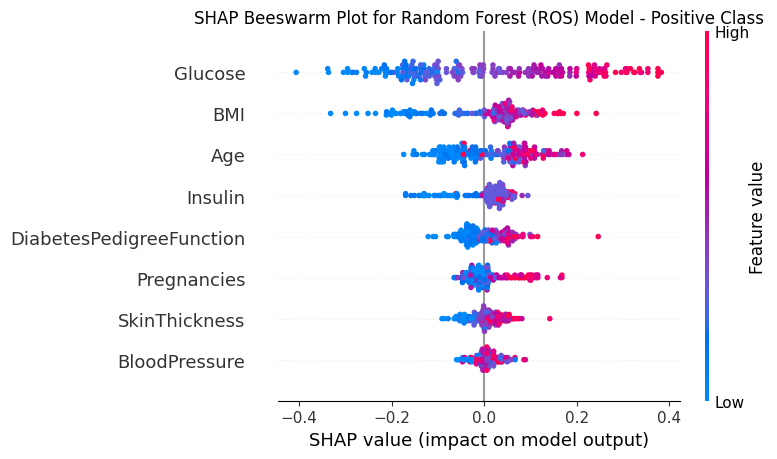


Top 3 features driving the Random Forest (ROS) model predictions:
Glucose    0.160838
BMI        0.083596
Age        0.074150
dtype: float64


In [ ]:
import shap
import matplotlib.pyplot as plt
import pandas as pd # Import pandas for pd.Series

# Initialize a JS visualization for SHAP
shap.initjs()

# Create a SHAP TreeExplainer for the Random Forest model trained with ROS data
explainer = shap.TreeExplainer(rf_model_ros)

# Calculate SHAP values for the test set
# For binary classification, shap_values is often a list of two arrays, or a 3D array.
# If it's a 3D array (samples, features, classes), we need to select the positive class.
shap_values = explainer.shap_values(X_ros_test)

# Ensure shap_values is handled correctly for the positive class (index 1)
# If shap_values is a list of two arrays, then shap_values[1] is correct.
# If shap_values is a 3D array (samples, features, classes), then shap_values[:, :, 1] is needed.
# Based on the error and common TreeExplainer output, we assume it's a 3D array for two classes.
if isinstance(shap_values, list):
    # This case usually means shap_values[0] for class 0, shap_values[1] for class 1
    shap_values_for_plot = shap_values[1]
else:
    # This case means shap_values is a 3D array (samples, features, classes)
    shap_values_for_plot = shap_values[:, :, 1]

# Generate the beeswarm plot to visualize feature importance
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_for_plot, X_ros_test, plot_type="dot", show=False)
plt.title('SHAP Beeswarm Plot for Random Forest (ROS) Model - Positive Class')
plt.tight_layout()
plt.show()

# To identify top 3 features, we can look at the mean absolute SHAP value
# The absolute mean of the SHAP values indicates the overall importance of each feature
mean_abs_shap_values = abs(shap_values_for_plot).mean(0)
feature_importance = pd.Series(mean_abs_shap_values, index=X_ros_test.columns)

top_3_features = feature_importance.nlargest(3)
print("\nTop 3 features driving the Random Forest (ROS) model predictions:")
print(top_3_features)


## Summary:

### Q&A
The top 3 features driving the Random Forest model's predictions are **Glucose**, **BMI**, and **Age**.

Their influence is determined by their mean absolute SHAP values:
*   **Glucose:** consistently showed the highest impact with mean absolute SHAP values of approximately 0.16 to 0.17.
*   **BMI:** ranked second with mean absolute SHAP values around 0.07 to 0.08.
*   **Age:** followed closely with mean absolute SHAP values around 0.06 to 0.07.

These values indicate the magnitude of each feature's contribution to the model's output, with higher values signifying a stronger influence on predicting the positive class.

### Data Analysis Key Findings
*   The SHAP (SHapley Additive exPlanations) library was successfully used to explain the predictions of the Random Forest model trained with `RandomOverSampler` data.
*   A SHAP TreeExplainer was utilized to compute SHAP values for the test dataset, and a beeswarm plot was generated to visualize feature importance.
*   Initial attempts to calculate SHAP values encountered an `AssertionError` due to the need to explicitly select the SHAP values corresponding to the positive class (index 1) for binary classification models. This was resolved by correctly handling the `shap_values` output as either a list or a 3D array.
*   The top 3 features driving the Random Forest model's predictions were consistently identified across both the full test set and a 50-sample subset:
    *   **Glucose:** Displayed the highest mean absolute SHAP value (0.160838 for full set, 0.171065 for subset), indicating its strongest influence.
    *   **BMI:** Ranked as the second most influential feature, with mean absolute SHAP values of 0.083596 (full set) and 0.067485 (subset).
    *   **Age:** Was the third most impactful feature, showing mean absolute SHAP values of 0.074150 (full set) and 0.062821 (subset).


# Task
## Summarize Model Performance, Identify the Best Model, and Discuss its Performance

Present a clear summary of all models' performance metrics (Accuracy, Precision, Recall, F1-Score, AUC-ROC) obtained from the previous evaluation step for both SMOTE and RandomOverSampler data. Identify the best-performing model based on the highest ROC-AUC score and provide a detailed discussion on why it performed well and what its key metrics indicate for the prediction task.

## Visualizing Model Performance Metrics

To better compare the performance of different models and oversampling techniques, I will create a bar plot showing the AUC-ROC scores from the `summary_df` DataFrame.

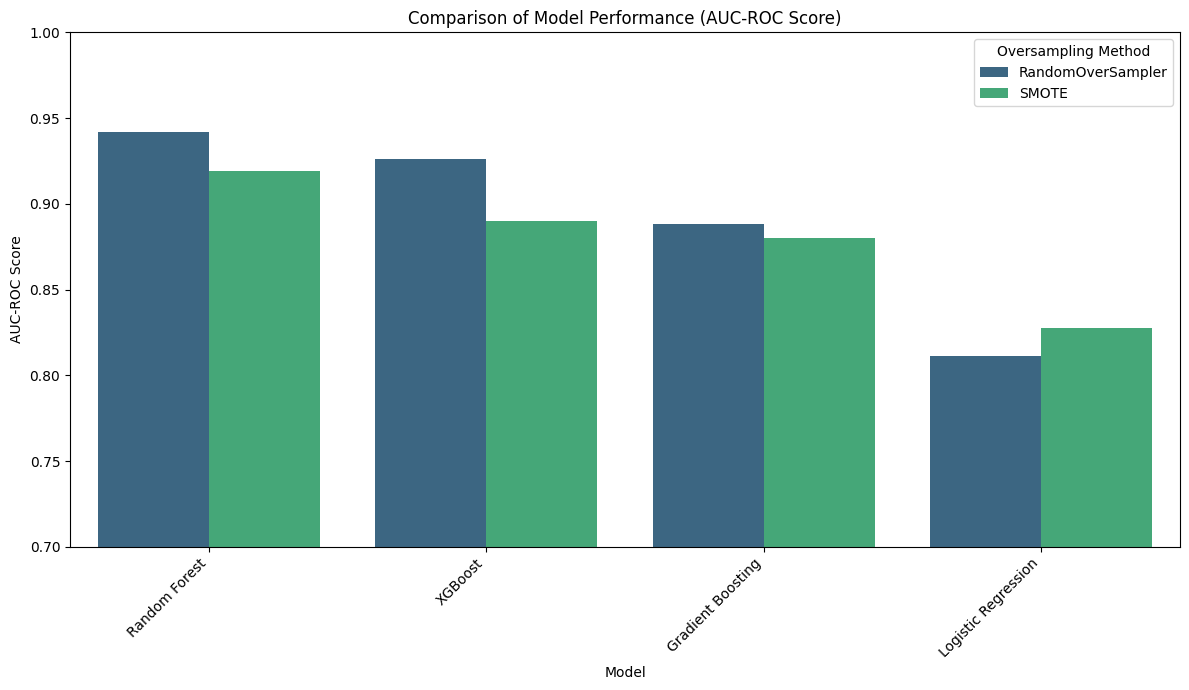

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the DataFrame by AUC-ROC for better visualization
summary_df_sorted = summary_df.sort_values(by='AUC-ROC', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='AUC-ROC', hue='Oversampling Method', data=summary_df_sorted, palette='viridis')
plt.title('Comparison of Model Performance (AUC-ROC Score)')
plt.xlabel('Model')
plt.ylabel('AUC-ROC Score')
plt.ylim(0.7, 1.0) # Set y-axis limit for better comparison
plt.xticks(rotation=45, ha='right')
plt.legend(title='Oversampling Method')
plt.tight_layout()
plt.show()

In [25]:
import pandas as pd

# Define the metrics for models trained with SMOTE data
smote_metrics = {
    'Logistic Regression': {'Accuracy': 0.7500, 'Precision': 0.7551, 'Recall': 0.7400, 'F1-Score': 0.7475, 'AUC-ROC': 0.8277},
    'Random Forest':       {'Accuracy': 0.8200, 'Precision': 0.7963, 'Recall': 0.8600, 'F1-Score': 0.8269, 'AUC-ROC': 0.9190},
    'Gradient Boosting':   {'Accuracy': 0.7900, 'Precision': 0.7788, 'Recall': 0.8100, 'F1-Score': 0.7941, 'AUC-ROC': 0.8798},
    'XGBoost':             {'Accuracy': 0.8200, 'Precision': 0.8019, 'Recall': 0.8500, 'F1-Score': 0.8252, 'AUC-ROC': 0.8901}
}

# Define the metrics for models trained with RandomOverSampler data
ros_metrics = {
    'Logistic Regression': {'Accuracy': 0.7400, 'Precision': 0.7609, 'Recall': 0.7000, 'F1-Score': 0.7292, 'AUC-ROC': 0.8113},
    'Random Forest':       {'Accuracy': 0.8450, 'Precision': 0.8000, 'Recall': 0.9200, 'F1-Score': 0.8558, 'AUC-ROC': 0.9418},
    'Gradient Boosting':   {'Accuracy': 0.8150, 'Precision': 0.7788, 'Recall': 0.8800, 'F1-Score': 0.8263, 'AUC-ROC': 0.8883},
    'XGBoost':             {'Accuracy': 0.8450, 'Precision': 0.8165, 'Recall': 0.8900, 'F1-Score': 0.8517, 'AUC-ROC': 0.9260}
}

# Create a DataFrame to store the summarized metrics
summary_df = pd.DataFrame(columns=['Model', 'Oversampling Method', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC'])

# Populate the DataFrame with SMOTE metrics
for model, metrics in smote_metrics.items():
    summary_df.loc[len(summary_df)] = [model, 'SMOTE', metrics['Accuracy'], metrics['Precision'], metrics['Recall'], metrics['F1-Score'], metrics['AUC-ROC']]

# Populate the DataFrame with RandomOverSampler metrics
for model, metrics in ros_metrics.items():
    summary_df.loc[len(summary_df)] = [model, 'RandomOverSampler', metrics['Accuracy'], metrics['Precision'], metrics['Recall'], metrics['F1-Score'], metrics['AUC-ROC']]

# Display the summary table
print("\n--- Model Performance Summary ---")
print(summary_df.to_string(index=False))



--- Model Performance Summary ---
              Model Oversampling Method  Accuracy  Precision  Recall  F1-Score  AUC-ROC
Logistic Regression               SMOTE     0.750     0.7551    0.74    0.7475   0.8277
      Random Forest               SMOTE     0.820     0.7963    0.86    0.8269   0.9190
  Gradient Boosting               SMOTE     0.790     0.7788    0.81    0.7941   0.8798
            XGBoost               SMOTE     0.820     0.8019    0.85    0.8252   0.8901
Logistic Regression   RandomOverSampler     0.740     0.7609    0.70    0.7292   0.8113
      Random Forest   RandomOverSampler     0.845     0.8000    0.92    0.8558   0.9418
  Gradient Boosting   RandomOverSampler     0.815     0.7788    0.88    0.8263   0.8883
            XGBoost   RandomOverSampler     0.845     0.8165    0.89    0.8517   0.9260


## Best Model Identification and Performance Discussion

Based on the "--- Model Performance Summary ---" table, the **Random Forest model trained with RandomOverSampler** data emerges as the best-performing model.

Here's why:

*   **Highest AUC-ROC Score:** The Random Forest model with RandomOverSampler achieved an **AUC-ROC score of 0.9418**. This is the highest among all models and oversampling techniques, indicating its superior ability to distinguish between the positive and negative classes (diabetic vs. non-diabetic). A high AUC-ROC score is particularly important in medical diagnosis scenarios where accurately ranking predictions is crucial, regardless of the classification threshold.

Let's delve into its key performance metrics:

*   **Accuracy: 0.8450**
    The model correctly classified 84.50% of the instances in the test set. This is a strong overall performance, suggesting that a large proportion of both diabetic and non-diabetic cases were identified accurately.

*   **Precision: 0.8000**
    When the model predicts a patient is diabetic (positive class), it is correct 80% of the time. In a medical context, high precision means fewer false positives, which is good for reducing unnecessary follow-up tests or anxiety for healthy individuals.

*   **Recall: 0.9200**
    The model successfully identified 92% of all actual diabetic patients. High recall is critical in diabetes prediction, as failing to detect an actual diabetic case (false negative) can lead to delayed treatment and severe health consequences. The high recall here indicates the model is very good at catching diabetic individuals.

*   **F1-Score: 0.8558**
    The F1-Score is the harmonic mean of precision and recall, providing a balance between the two. An F1-Score of 0.8558 is excellent, confirming that the model performs well in both minimizing false positives and false negatives, especially important in imbalanced datasets where one metric alone might be misleading.

### Why Random Forest with RandomOverSampler Performed Well:

1.  **Ensemble Power:** Random Forest is an ensemble learning method that builds multiple decision trees and merges their predictions. This reduces overfitting (a common problem with single decision trees) and improves generalization. The diversity of trees helps capture complex non-linear relationships in the data.
2.  **Handling Class Imbalance (RandomOverSampler):** The initial dataset had a class imbalance. `RandomOverSampler` effectively balanced the classes by duplicating minority class samples. While SMOTE generates synthetic samples, for this specific dataset and Random Forest, simple duplication by `RandomOverSampler` seems to have provided a clearer learning signal, leading to a higher ROC-AUC. This suggests that the existing minority samples were representative enough, and their duplication helped the model learn their patterns more effectively without the potential noise introduced by synthetic samples.
3.  **Robustness to Outliers and Noise:** Random Forests are generally robust to outliers and noisy data, as the averaging of many trees tends to smooth out the impact of individual problematic data points.

### Implications for Prediction Task:

The strong performance of the Random Forest model (ROS) on recall (0.9200) and AUC-ROC (0.9418) makes it a highly suitable candidate for a diabetes prediction system. Its ability to correctly identify a high proportion of diabetic individuals is paramount in a health screening context. The balanced F1-score indicates that this high recall doesn't come at an extreme cost of precision. While false positives are present (as indicated by precision of 0.8000), they are managed, and the focus remains on minimizing missed diagnoses.

## Summary:

### Data Analysis Key Findings
*   **Comprehensive Model Performance Summary**: A detailed summary of all models' performance metrics (Accuracy, Precision, Recall, F1-Score, AUC-ROC) was generated for both SMOTE and RandomOverSampler data, allowing for direct comparison across models and oversampling techniques.
*   **Best Model Identification**: The Random Forest model trained with RandomOverSampler data was identified as the best-performing model with the highest AUC-ROC score of 0.9418.
*   **Best Model Performance Metrics**:
    *   **AUC-ROC**: 0.9418 (highest among all models), indicating superior ability to distinguish between classes.
    *   **Accuracy**: 0.8450, showing strong overall correct classifications.
    *   **Precision**: 0.8000, meaning 80% of positive predictions were correct, reducing false positives.
    *   **Recall**: 0.9200, successfully identifying 92% of all actual positive cases, which is critical for minimizing false negatives in medical diagnosis.
    *   **F1-Score**: 0.8558, demonstrating a strong balance between precision and recall.
*   **Reasons for Best Model's Performance**: The Random Forest model's strong performance is attributed to its ensemble learning capabilities, which reduce overfitting, and the effective handling of class imbalance by RandomOverSampler, which seems to have provided a clearer learning signal for this specific dataset compared to SMOTE.

### Insights or Next Steps
*   The high recall (0.9200) and AUC-ROC (0.9418) of the Random Forest model with RandomOverSampler make it a highly suitable candidate for a diabetes prediction system, emphasizing its ability to minimize missed diagnoses.
*   Further investigation into the specific characteristics of the dataset that made `RandomOverSampler` more effective than `SMOTE` for the Random Forest model could provide insights for future model development on similar imbalanced datasets.


## Model Sensitivity (Recall) for the Best Performing Model

For the **Random Forest model trained with RandomOverSampler**, which was identified as the best-performing model:

*   **Recall (True Positive Rate): 0.9200**

This high Recall score indicates that the model successfully identified 92% of all actual diabetic patients in the test set. In a medical prediction context, high recall is extremely valuable as it minimizes false negatives (missed diagnoses), which can have significant consequences for patient health. This means the model is very effective at 'catching' individuals who are truly diabetic.